In [1]:
# General Imports
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

# Global Hyperparameters
path_to_results = '/Users/nick_1/PycharmProjects/UWO Masters/ICML_Jun12_Results'
save_folder = '/Users/nick_1/PycharmProjects/UWO Masters/PdM_Predictor/04_ICML_Revised_Results'

# Merge Results Into 2 CSV Files

In [2]:
from utils import merge_results

# Merge Results
merge_results(path_to_results, save_folder)

/Users/nick_1/PycharmProjects/UWO Masters/PdM_Predictor/04_ICML_Revised_Results/utils.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, current_df], ignore_index=True)
/Users/nick_1/PycharmProjects/UWO Masters/PdM_Predictor/04_ICML_Revised_Results/utils.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, current_df], ignore_index=True)


Done - results merged


# Calculate Training Time for All Models

In [3]:
from utils import create_training_time_csv

# create csv file with training time
create_training_time_csv(path_to_results, save_folder)

Done - training time csv created


# Calculate Fouling Percentage for CGS and SMS Datasets

In [4]:
from utils import calculate_CGS_fouling_percentage, calculate_SMS_fouling_percentage

# Hyperparameters
path_to_CGS_ds = '/Users/nick_1/PycharmProjects/UWO Masters/data_60/mar28_ds4' # CGS
path_to_SMS_ds = '/Users/nick_1/PycharmProjects/UWO Masters/data_60/mar28_ds5' # SMS

calculate_CGS_fouling_percentage(path_to_CGS_ds, save_folder)
calculate_SMS_fouling_percentage(path_to_SMS_ds, save_folder)

/Users/nick_1/PycharmProjects/UWO Masters/PdM_Predictor/04_ICML_Revised_Results/utils.py:159: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame(row_dict, index=[0])], ignore_index=True)


Done - CGS fouling percentage csv created


/Users/nick_1/PycharmProjects/UWO Masters/PdM_Predictor/04_ICML_Revised_Results/utils.py:181: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame(row_dict, index=[0])], ignore_index=True)


Done - SMS fouling percentage csv created


# Calculate Mean F1 Score for CGS and SMS Binary Results

In [5]:
path_to_binary_results = os.path.join(save_folder, 'binary_results.csv')

df_binary = pd.read_csv(path_to_binary_results)
# print(df_binary.head())

df_CGS = df_binary[df_binary['Scenario'] == 'CGS']
df_SMS = df_binary[df_binary['Scenario'] == 'SMS']

print("----- Binary Results ONLY -----")
print(f"Average F1 Score CGS: {df_CGS['F1 Score'].mean():.4f}")
print(f"Average F1 Score SMS: {df_SMS['F1 Score'].mean():.4f}")

----- Binary Results ONLY -----
Average F1 Score CGS: 0.9768
Average F1 Score SMS: 0.9426


# Create SMS Multiclass Results Timeline Figure

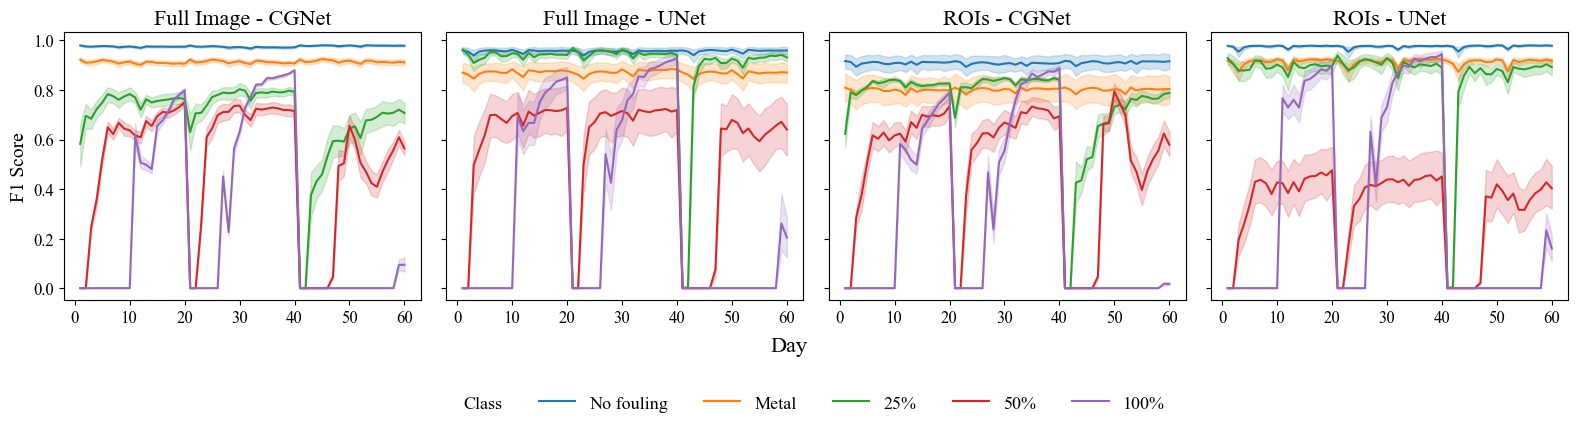

In [6]:
from matplotlib.lines import Line2D

path_to_multiclass_results = os.path.join(save_folder, 'multiclass_results.csv')
df_multiclass = pd.read_csv(path_to_multiclass_results)
df_SMS = df_multiclass[df_multiclass['Scenario'] == 'SMS']
df = df_SMS

# Define which classes to drop
drop_class = [3, 5]

# Original list of F1 columns
all_f1_columns = [
    'Class 0 F1 Score', 'Class 1 F1 Score', 'Class 2 F1 Score',
    'Class 3 F1 Score', 'Class 4 F1 Score', 'Class 5 F1 Score',
    'Class 6 F1 Score'
]

# Filter out the columns you want to drop
f1_columns = [
    col for col in all_f1_columns
    if int(col.split()[1]) not in drop_class
]

# Melt the DataFrame
df_melted = df.melt(
    id_vars=['CNN Model', 'Input Type', 'Target Type', 'Day', 'Hour'],
    value_vars=f1_columns,
    var_name='Class',
    value_name='F1 Score'
)

# Extract class number
df_melted['Class'] = df_melted['Class'].str.extract(r'Class (\d+) F1 Score').astype(int)

df_melted

# Set global font size and font family to Times New Roman
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'font.family': 'serif',
    'font.serif': ['Times New Roman']
})

# Class mapping
class_map = {
    0: 'No fouling',
    1: 'Metal',
    2: '25%',
    4: '50%',
    6: '100%'
}

# Filter and relabel
df_filtered = df_melted[df_melted['Class'].isin(class_map.keys())].copy()
df_filtered['Class Label'] = df_filtered['Class'].map(class_map)

# Subplot combinations
combinations = [
    ('full', 'cgnet'),
    ('full', 'unet'),
    ('rois', 'cgnet'),
    ('rois', 'unet')
]

titles = [
    'Full Image - CGNet',
    'Full Image - UNet',
    'ROIs - CGNet',
    'ROIs - UNet'
]

# Create subplots
num_plots = len(combinations)
fig, axes = plt.subplots(1, num_plots, figsize=(16, 4), sharey=True, sharex=True)

for i, ((input_type, model), ax, title) in enumerate(zip(combinations, axes, titles)):
    mask = (df_filtered['CNN Model'] == model) & (df_filtered['Input Type'] == input_type)
    to_plot = df_filtered.loc[mask]

    sns.lineplot(x="Day", y="F1 Score", hue="Class Label", ax=ax, data=to_plot)
    ax.set_title(title)
    # Remove individual x-axis labels
    ax.set_xlabel("")
    if i == 0:
        ax.set_ylabel("F1 Score")
    else:
        ax.set_ylabel("")
    ax.legend_.remove()  # Remove subplot legends

# Set shared x-axis label, but move it further upwards by increasing y
fig.supxlabel("Day", fontsize=16, y=0.08)  # Default is y=0.01, so 0.08 moves it up

# Create dummy handle for "Class" label
class_label_handle = Line2D([], [], color='none', label='Class')

# Get existing handles and labels
handles, labels = axes[0].get_legend_handles_labels()

# Insert the dummy handle at the beginning
handles.insert(0, class_label_handle)
labels.insert(0, "Class")

# Add shared horizontal legend below
fig.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.show()

# Plot the Training Time in Minutes

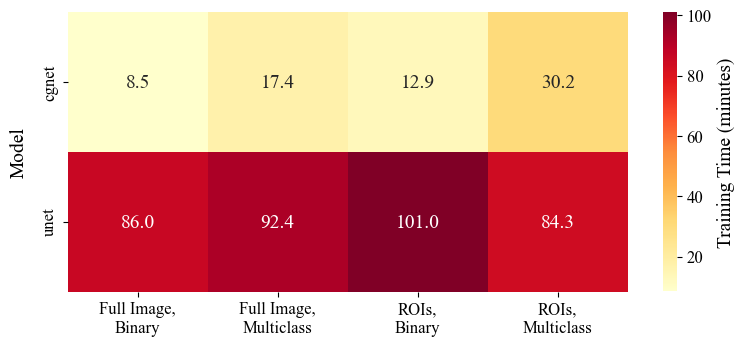

In [7]:
df = pd.read_csv(os.path.join(save_folder, 'training_time_plot.csv'))

# Convert training_time from HH:MM:SS to minutes for numeric plotting
def time_to_minutes(time_str):
    if pd.isna(time_str) or time_str == 'N/A':
        return np.nan
    h, m, s = time_str.split(':')
    return int(h) * 60 + int(m) + float(s) / 60

df['training_time_minutes'] = df['training_time'].apply(time_to_minutes)

# Create faceted heatmap using seaborn
plt.figure(figsize=(8, 6))
pivot_df = df.pivot_table(
    values='training_time_minutes',
    index='model',
    columns=['roi_mode', 'target_mode'],
    aggfunc='mean'
)

# Format column labels with newline after comma
new_columns = []
for roi_mode, target_mode in pivot_df.columns:
    roi_label = 'Full Image' if roi_mode == 'full' else 'ROIs'
    target_label = 'Multiclass' if target_mode == 'multiclass' else 'Binary'
    new_columns.append(f"{roi_label},\n{target_label}")
pivot_df.columns = new_columns

# Create heatmap with improved formatting
ax = sns.heatmap(pivot_df, 
            annot=True, 
            cmap='YlOrRd', 
            fmt='.1f',  # Changed to 1 decimal place for minutes
            cbar_kws={'label': 'Training Time (minutes)', 'shrink': 0.5},  # Added shrink parameter
            square=True)  # Make cells square

# Make x axis labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Improve title and labels
plt.ylabel('Model', labelpad=10)

# Adjust layout
plt.tight_layout()
plt.show()

# Plot the Binary CGS Confusion Matrix

Total TP: 19.27384140751446, Total FP: 0.26746881713552667, Total FN: 0.23116157275858065, Total TN: 80.22752820259143, Total: 17635968000


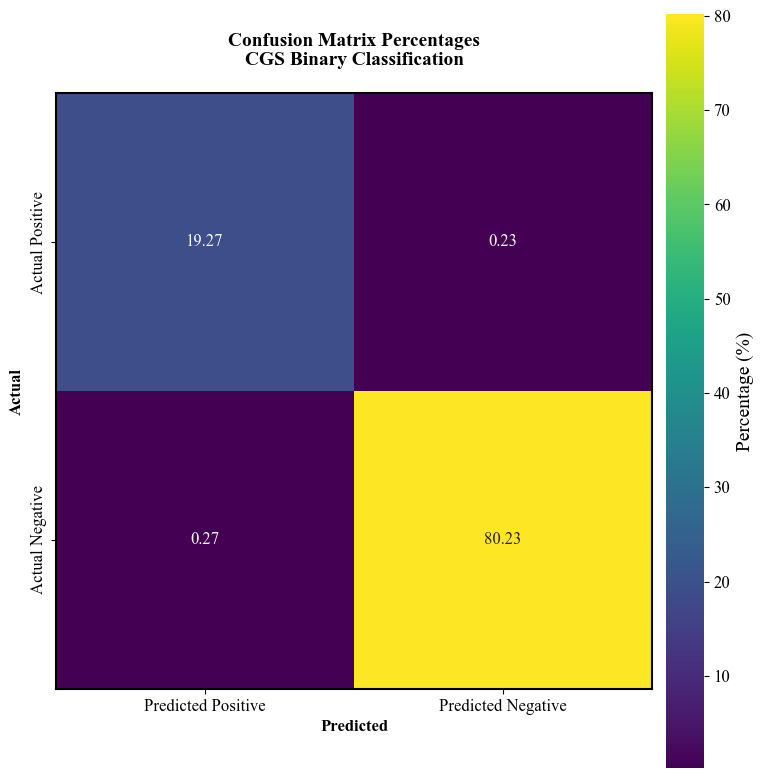

In [8]:
df_cgs_binary = pd.read_csv(os.path.join(save_folder, 'binary_results.csv'))
df_cgs_binary = df_cgs_binary[df_cgs_binary['Scenario'] == 'CGS']

# Calculate overall percentage confusion matrix by summing all values first
total_tp = df_cgs_binary['TP'].sum()
total_fp = df_cgs_binary['FP'].sum()
total_fn = df_cgs_binary['FN'].sum()
total_tn = df_cgs_binary['TN'].sum()
total = total_tp + total_fp + total_fn + total_tn

print(f"Total TP: {total_tp / total * 100}, Total FP: {total_fp / total * 100}, Total FN: {total_fn / total * 100}, Total TN: {total_tn / total * 100}, Total: {total}")

# Create 4x4 confusion matrix percentages
confusion_matrix = pd.DataFrame({
    'Predicted Positive': [total_tp / total * 100, total_fp / total * 100],
    'Predicted Negative': [total_fn / total * 100, total_tn / total * 100]
}, index=['Actual Positive', 'Actual Negative'])

# Set style for IEEE paper
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Create visualization with improved styling for IEEE
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_matrix, 
            annot=True, 
            cmap='viridis',
            fmt='.2f',
            cbar_kws={'label': 'Percentage (%)', 'pad': 0.02},
            square=True,
            ax=ax,
            annot_kws={'size': 12})

# Improve title and labels
plt.title('Confusion Matrix Percentages\nCGS Binary Classification', 
          pad=20, 
          fontsize=14, 
          fontweight='bold')

# Adjust labels
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')

# Add border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

# Plot CGS vs SMS F1 Score Comparison Timeline

Computing precision & recall...
Drawing vertically stacked F1 plots...


/var/folders/33/4fqcfxgx5078w5btpn5rs85m0000gq/T/ipykernel_36007/2155181102.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cgs['Dataset'] = 'CGS'
/var/folders/33/4fqcfxgx5078w5btpn5rs85m0000gq/T/ipykernel_36007/2155181102.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sms['Dataset'] = 'SMS'


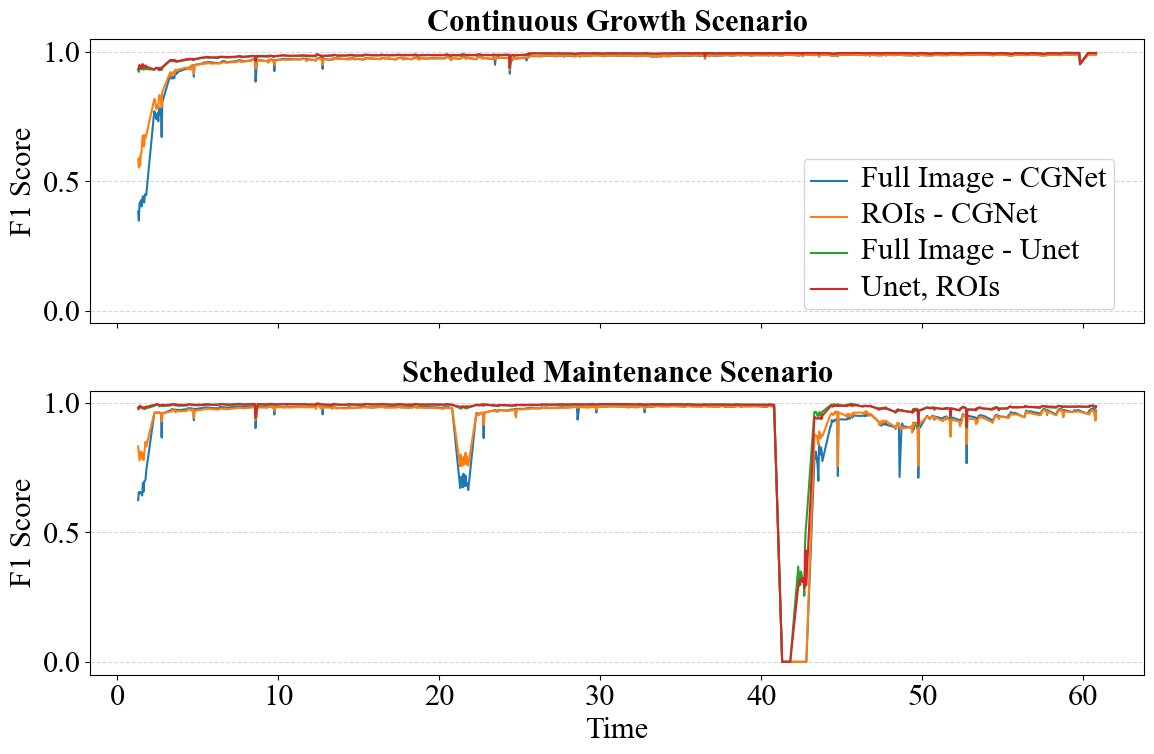

In [9]:
# 1) Load each CSV and tag its dataset
df_binary = pd.read_csv(os.path.join(save_folder, 'binary_results.csv'))

df_cgs = df_binary[df_binary['Scenario'] == 'CGS']
df_sms = df_binary[df_binary['Scenario'] == 'SMS']

df_cgs['Dataset'] = 'CGS'
df_sms['Dataset'] = 'SMS'

# Set global font to Times New Roman and consistent font size
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 22

# 2) Concatenate dataframes
df = pd.concat([df_cgs, df_sms], ignore_index=True)

hour_options = ['1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am', '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm', '12am']

# Map the Hour column to its index in hour_options (if Hour is a string like '8am', '9am', etc.)
df['Hour Index'] = df['Hour'].apply(lambda h: hour_options.index(h) if h in hour_options else None)

df['Time'] = df['Day'] + df['Hour Index'] / 24

print('Computing precision & recall...')

# 4) compute precision & recall
df['Precision'] = df['TP'] / (df['TP'] + df['FP'])
df['Recall']    = df['TP'] / (df['TP'] + df['FN'])

# 5) Aggregate data by trial number
df_agg = df.groupby(['Time','Dataset','CNN Model','Input Type']).agg({
    'Precision': 'mean',
    'Recall': 'mean',
    'F1 Score': 'mean'
}).reset_index()

df_agg['Combo Type'] = df_agg['CNN Model'] + ' + ' + df_agg['Input Type']

df_agg['Combo Type'] = df_agg['Combo Type'].str.replace('cgnet + full', 'Full Image - CGNet')
df_agg['Combo Type'] = df_agg['Combo Type'].str.replace('cgnet + rois', 'ROIs - CGNet')

df_agg['Combo Type'] = df_agg['Combo Type'].str.replace('unet + full', 'Full Image - Unet')
df_agg['Combo Type'] = df_agg['Combo Type'].str.replace('unet + rois', 'Unet, ROIs')

print('Drawing vertically stacked F1 plots...')

# Prepare the data for each dataset
datasets = ['CGS', 'SMS']
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharey=True, sharex=True)

for i, dataset in enumerate(datasets):
    ax = axes[i]
    df_plot = df_agg[df_agg['Dataset'] == dataset]
    for combo in df_plot['Combo Type'].unique():
        df_combo = df_plot[df_plot['Combo Type'] == combo].sort_values('Time')
        ax.plot(df_combo['Time'], df_combo['F1 Score'], label=combo)
    ax.set_title(f'{dataset.replace("CGS", "Continuous Growth Scenario").replace("SMS", "Scheduled Maintenance Scenario")}', fontsize=22, fontweight='bold', fontname='Times New Roman')
    ax.set_ylabel('F1 Score', fontsize=22, fontname='Times New Roman')
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
    if i == 1:
        ax.set_xlabel('Time', fontsize=22, fontname='Times New Roman')
    else:
        ax.set_xlabel('')
    if i == 0:
        # Only show legend on the top plot, near the bottom-right
        legend = ax.legend(
            bbox_to_anchor=(0.98, 0.02),
            loc='lower right',
            frameon=True
        )
        plt.setp(legend.get_texts(), fontsize=22, fontname='Times New Roman')
        plt.setp(legend.get_title(), fontsize=22, fontname='Times New Roman')

# Set tick label font properties for all axes
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=22)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')
        label.set_fontsize(22)

plt.tight_layout()
plt.show()

# Plot TPR and FPR for Different Model + Input Combos

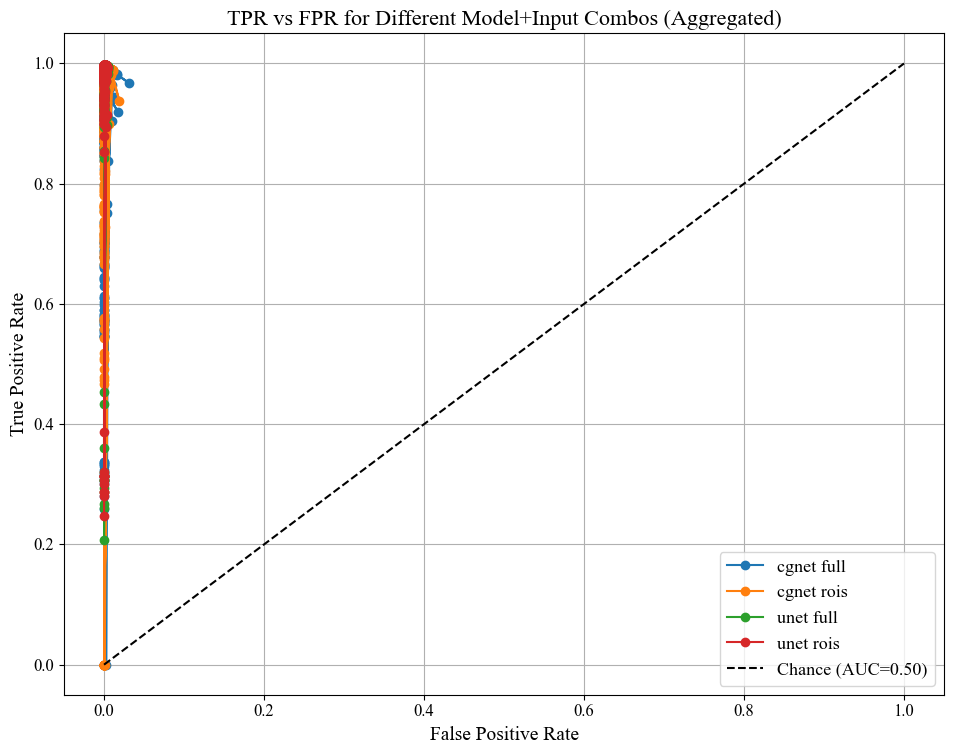

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# 1) Load each CSV and tag its dataset
df = pd.read_csv(os.path.join(save_folder, 'binary_results.csv'))

# 2) Concatenate dataframes
df = pd.concat([df_cgs, df_sms], ignore_index=True)

hour_options = ['1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am', '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm', '12am']

# Map the Hour column to its index in hour_options (if Hour is a string like '8am', '9am', etc.)
df['Hour Index'] = df['Hour'].apply(lambda h: hour_options.index(h) if h in hour_options else None)

df['Time'] = df['Day'] + df['Hour Index'] / 24

# 5) Aggregate data by trial number
df_agg = df.groupby(['Time','Scenario','CNN Model','Input Type']).agg({
    'TP': 'mean',
    'FP': 'mean',
    'FN': 'mean',
    'TN': 'mean'
}).reset_index()

df_agg['Combo Type'] = df_agg['CNN Model'] + ' ' + df_agg['Input Type']

plt.figure(figsize=(10, 8))
for combo in df_agg['Combo Type'].unique():
    df_combo = df_agg[df_agg['Combo Type'] == combo].sort_values('Time')
    
    # Calculate TPR and FPR for each time point
    tpr = df_combo['TP'] / (df_combo['TP'] + df_combo['FN'])
    fpr = df_combo['FP'] / (df_combo['FP'] + df_combo['TN'])
    
    plt.plot(fpr, tpr, marker='o', label=f"{combo}")

# chance line
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC=0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TPR vs FPR for Different Model+Input Combos (Aggregated)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()